In [4]:
import numpy as np
import pandas as pd
import os

# 1. Re-initialize our statistical states
PROCESSED_MATRIX_PATH = os.path.join("..", "data", "processed", "vectorized_matrix.npy")
X = np.load(PROCESSED_MATRIX_PATH)

# Re-run our fast column entropy to acquire the gradient array
def get_gradients(matrix):
    N, M = matrix.shape
    entropy = np.array([-np.sum((c/N)*np.log2((c/N)+1e-12)) for c in [np.unique(matrix[:,j], return_counts=True)[1] for j in range(M)]])
    return np.abs(np.diff(entropy, prepend=0))

delta_gradient = get_gradients(X)

# 2. Set an empirical threshold to identify major field transitions (e.g., variance shifts > 0.5 bits)
GRADIENT_THRESHOLD = 0.5
boundary_indices = np.where(delta_gradient > GRADIENT_THRESHOLD)[0]

# 3. Assemble fields sequentially based on discovered split points
fields = []
start_offset = 0

for idx, boundary in enumerate(boundary_indices):
    if boundary == 0:
        continue
    fields.append({
        "Field Name": f"Discovered_Field_{len(fields)}",
        "Byte Range": f"{start_offset} - {boundary - 1}",
        "Length (Bytes)": boundary - start_offset
    })
    start_offset = boundary

# Catch the remaining tail field
fields.append({
    "Field Name": f"Discovered_Field_{len(fields)}",
    "Byte Range": f"{start_offset} - {X.shape[1] - 1}",
    "Length (Bytes)": X.shape[1] - start_offset
})

# Display your completely reverse-engineered protocol schema!
layout_df = pd.DataFrame(fields)
layout_df

,Field Name,Byte Range,Length (Bytes)
0,Discovered_Field_0,0 - 6,7
1,Discovered_Field_1,7 - 7,1
2,Discovered_Field_2,8 - 11,4
3,Discovered_Field_3,12 - 13,2
4,Discovered_Field_4,14 - 16,3
5,Discovered_Field_5,17 - 17,1
6,Discovered_Field_6,18 - 18,1
7,Discovered_Field_7,19 - 21,3
8,Discovered_Field_8,22 - 23,2
9,Discovered_Field_9,24 - 26,3


In [3]:
import numpy as np
import pandas as pd
import os

# 1. Re-initialize our statistical states
PROCESSED_MATRIX_PATH = os.path.join("..", "data", "processed", "vectorized_matrix.npy")
X = np.load(PROCESSED_MATRIX_PATH)

def discover_protocol_fields(matrix: np.ndarray, 
                             min_field_size: int = 2,
                             gradient_threshold: float = 0.4):
    
    N, M = matrix.shape
    # Compute entropy per byte position
    entropies = np.array([
        -np.sum((c/N) * np.log2((c/N) + 1e-12)) 
        for c in [np.unique(matrix[:, j], return_counts=True)[1] for j in range(M)]
    ])
    
    delta = np.abs(np.diff(entropies, prepend=0))
    
    # Find significant boundaries
    boundaries = np.where(delta > gradient_threshold)[0]
    boundaries = boundaries[boundaries > 0]
    
    # Merge close boundaries to avoid over-fragmentation
    merged = []
    for b in boundaries:
        if not merged or b - merged[-1] >= min_field_size:
            merged.append(b)
    
    # Build fields
    fields = []
    start = 0
    for end in merged:
        fields.append({
            "Field": f"Field_{len(fields)}",
            "Start": start,
            "End": end - 1,
            "Length": end - start,
            "Mean_Entropy": round(entropies[start:end].mean(), 4)
        })
        start = end
    
    # Final field
    fields.append({
        "Field": f"Field_{len(fields)}",
        "Start": start,
        "End": M - 1,
        "Length": M - start,
        "Mean_Entropy": round(entropies[start:].mean(), 4)
    })
    
    return pd.DataFrame(fields)


# Usage
layout_df = discover_protocol_fields(X, min_field_size=2, gradient_threshold=0.45)
layout_df

,Field,Start,End,Length,Mean_Entropy
0,Field_0,0,6,7,-0.0000
1,Field_1,7,11,5,0.3028
2,Field_2,12,13,2,5.9169
3,Field_3,14,16,3,0.5265
4,Field_4,17,18,2,1.9559
5,Field_5,19,21,3,1.0578
6,Field_6,22,23,2,4.5918
7,Field_7,24,26,3,0.4966
8,Field_8,27,41,15,0.2457


# 5.1 Field Variability Index (FVI)

## Motivation
While Shannon Entropy $H(M)$ provides a robust mathematical foundation for measuring positional variance, absolute entropy values are highly dependent on the state space and the specific protocol environment. A threshold that correctly isolates boundaries in ARP (where max empirical entropy might be ~6 bits) will likely fail on IEC 60870-5-104 or encrypted DNP3 payloads where entropy approaches the theoretical maximum. To ensure our methodology remains generic and extensible to Industrial Control Systems (ICS), we must project these absolute values into a standardized, protocol-agnostic domain.

## Research Objective
The objective of this stage is to compute the Field Variability Index (FVI), a normalized metric that maps column-wise entropy into a standard interval $[0, 1]$. This normalization allows us to definitively categorize protocol fields into specific typologies (e.g., Invariant Headers, Status/Control Flags, Dynamic Addresses) regardless of the underlying protocol structure.

## Connection to the Literature
This method directly implements the variance normalization concepts discussed in the *Byte-Pattern-Based* segmentation sections of the survey paper. Specifically, it approximates the field classification heuristics utilized by pioneering protocol reverse engineering frameworks like Netzob and IPRFW, which rely on normalized variability indices to filter out static structural padding before applying dynamic boundary merging techniques.

## Advantages & Limitations
* **Advantages:** Decouples boundary thresholding from the protocol's specific byte distribution, allowing for universal hyperparameter tuning in later stages.
* **Limitations:** FVI treats all byte distributions equally. A field with uniform random noise and a field with highly structured but diverse data (like a timestamp) might yield similar FVI scores.

## Mathematical Intuition

For a given byte offset $j$ in the tensor matrix $\mathbf{X}$, the raw Shannon Entropy is bounded by the maximum possible entropy of the system. For a single byte (8 bits), the theoretical state space $|V|$ is 256. 

The maximum theoretical entropy $H_{max}$ is defined as:
$$H_{max} = \log_2(|V|) = \log_2(256) = 8 \text{ bits}$$

The Field Variability Index $FVI(j)$ normalizes the positional entropy against this theoretical limit:
$$FVI(j) = \frac{H(M_j)}{H_{max}} = \frac{-\sum_{v \in V_j} P(v) \log_2 P(v)}{8}$$

Where:
* $FVI(j) \in [0, 1]$
* $FVI \to 0$: Indicates a static structural invariant (e.g., Magic Bytes, Protocol Version).
* $FVI \to 1$: Indicates maximum variance (e.g., Encrypted payloads, compressed data, highly dynamic random seeds).

**Computational Complexity:** Given that the raw entropy $H(M_j)$ has already been computed in $\mathcal{O}(N \times M)$, the FVI computation is an element-wise scalar division operating in $\mathcal{O}(M)$ time, making it highly efficient.

## Algorithm Design: FVI Computation & Typology Mapping

**Inputs:**
* `entropy_vector`: A 1D array of length $M$ containing absolute Shannon entropy values.
* `vocab_size`: The maximum number of discrete states per token (default is 256 for a standard byte).

**Outputs:**
* `fvi_vector`: A 1D array of length $M$ bounded between $[0, 1]$.
* `field_types`: A discrete classification vector assigning a semantic label to each offset.

**Design Decisions:**
We introduce empirical categorization boundaries to label the bytes prior to segmentation. 
* $FVI(j) \le \tau_{static}$: Classified as `Static` (Invariants).
* $\tau_{static} < FVI(j) \le \tau_{status}$: Classified as `Status/Control` (Opcodes, Flags).
* $FVI(j) > \tau_{status}$: Classified as `Dynamic` (Addresses, Payloads).

For this implementation, we initialize $\tau_{static} = 0.05$ and $\tau_{status} = 0.4$. These thresholds are easily adjustable when transitioning to Modbus or DNP3.

In [5]:
import os
import numpy as np
import pandas as pd

# Define paths to cached intermediate research artifacts
PROCESSED_DIR = os.path.join("..", "data", "processed")
ENTROPY_CACHE_PATH = os.path.join(PROCESSED_DIR, "entropy_profile.npy")

# Verify asset existence before loading to maintain pipeline safety guardrails
if not os.path.exists(ENTROPY_CACHE_PATH):
    raise FileNotFoundError(
        f"Missing tracking asset at {ENTROPY_CACHE_PATH}. "
        "Please execute Notebook 04 to completion to cache the entropy profiles first!"
    )

# Load the Shannon Entropy vector into the active notebook kernel namespace
entropy_profile = np.load(ENTROPY_CACHE_PATH)
print("--- INTERMEDIATE DATA PIPELINE RESTORED ---")
print(f"Successfully loaded entropy vector with dimension tracking shape: {entropy_profile.shape}")

--- INTERMEDIATE DATA PIPELINE RESTORED ---
Successfully loaded entropy vector with dimension tracking shape: (42,)


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, List

def compute_fvi(entropy_vector: np.ndarray, vocab_size: int = 256) -> np.ndarray:
    """
    Normalizes a Shannon entropy vector against the theoretical maximum entropy.
    
    Args:
        entropy_vector (np.ndarray): 1D array of raw entropy values per byte offset.
        vocab_size (int): The number of possible discrete states (256 for 1 byte).
        
    Returns:
        np.ndarray: The Field Variability Index vector bounded [0, 1].
    """
    h_max = np.log2(vocab_size)
    fvi_vector = entropy_vector / h_max
    
    # Clip to correct any floating point precision drift above 1.0 or below 0.0
    return np.clip(fvi_vector, 0.0, 1.0)

def categorize_fvi(fvi_vector: np.ndarray, 
                   tau_static: float = 0.05, 
                   tau_status: float = 0.4) -> List[str]:
    """
    Assigns semantic field typologies based on FVI thresholds.
    
    Args:
        fvi_vector (np.ndarray): Normalized variance array.
        tau_static (float): Upper bound for static invariant fields.
        tau_status (float): Upper bound for low-variance status/control fields.
        
    Returns:
        List[str]: Semantic labels for each byte offset.
    """
    categories = []
    for val in fvi_vector:
        if val <= tau_static:
            categories.append("Static (Invariant)")
        elif val <= tau_status:
            categories.append("Status/Control")
        else:
            categories.append("Dynamic (Payload/Address)")
    return categories

# --- Execution (Requires entropy_profile from Notebook 04) ---
# Assuming `entropy_profile` is loaded in memory from the previous stage:
fvi_profile = compute_fvi(entropy_profile)
fvi_categories = categorize_fvi(fvi_profile)

fvi_df = pd.DataFrame({
    "Raw Entropy (Bits)": entropy_profile,
    "FVI": fvi_profile,
    "Typology Label": fvi_categories
}, index=[f"Offset {i}" for i in range(len(fvi_profile))])

print("--- Field Variability Index Sample ---")
display(fvi_df.head(15))

--- Field Variability Index Sample ---


,Raw Entropy (Bits),FVI,Typology Label
Offset 0,-1.442823e-12,0.000000,Static (Invariant)
Offset 1,-1.442823e-12,0.000000,Static (Invariant)
Offset 2,-1.442823e-12,0.000000,Static (Invariant)
Offset 3,-1.442823e-12,0.000000,Static (Invariant)
Offset 4,-1.442823e-12,0.000000,Static (Invariant)
Offset 5,-1.442823e-12,0.000000,Static (Invariant)
Offset 6,-1.442823e-12,0.000000,Static (Invariant)
Offset 7,9.797735e-01,0.122472,Status/Control
Offset 8,-1.442823e-12,0.000000,Static (Invariant)
Offset 9,1.560632e-01,0.019508,Static (Invariant)


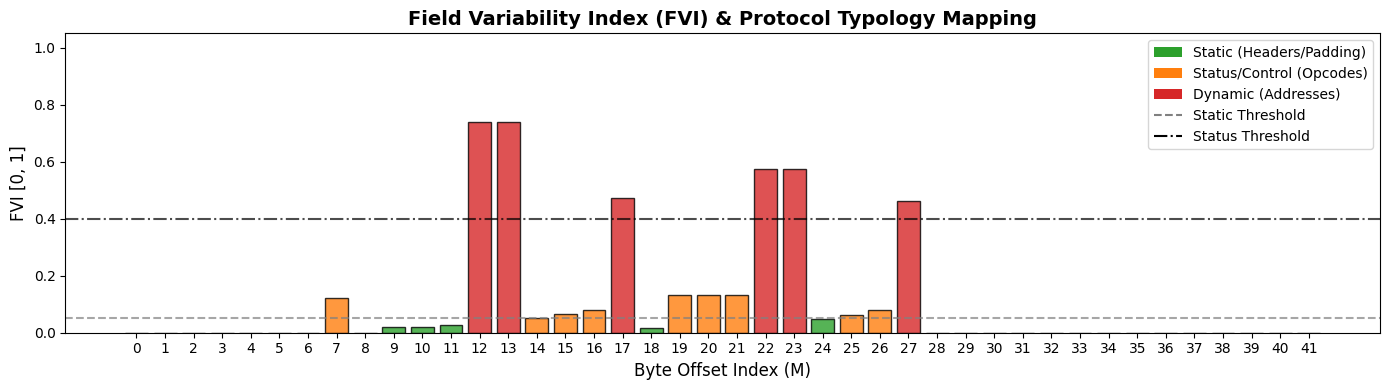

In [7]:
def plot_fvi_typology(fvi_vector: np.ndarray, tau_static: float = 0.05, tau_status: float = 0.4):
    """
    Generates a color-coded bar chart of the FVI to visualize structural typography.
    """
    plt.figure(figsize=(14, 4))
    
    M = len(fvi_vector)
    x_pos = np.arange(M)
    
    # Assign colors based on typology
    colors = []
    for val in fvi_vector:
        if val <= tau_static:
            colors.append('#2ca02c') # Green for Static
        elif val <= tau_status:
            colors.append('#ff7f0e') # Orange for Status
        else:
            colors.append('#d62728') # Red for Dynamic
            
    plt.bar(x_pos, fvi_vector, color=colors, edgecolor='black', alpha=0.8)
    
    # Draw Threshold Lines
    plt.axhline(y=tau_static, color='gray', linestyle='--', alpha=0.7, label=r'$\tau_{static}$')
    plt.axhline(y=tau_status, color='black', linestyle='-.', alpha=0.7, label=r'$\tau_{status}$')
    
    plt.title("Field Variability Index (FVI) & Protocol Typology Mapping", fontsize=14, fontweight='bold')
    plt.xlabel("Byte Offset Index (M)", fontsize=12)
    plt.ylabel("FVI [0, 1]", fontsize=12)
    plt.xticks(x_pos)
    plt.ylim(0, 1.05)
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ca02c', label='Static (Headers/Padding)'),
        Patch(facecolor='#ff7f0e', label='Status/Control (Opcodes)'),
        Patch(facecolor='#d62728', label='Dynamic (Addresses)'),
        plt.Line2D([0], [0], color='gray', linestyle='--', label=r'Static Threshold'),
        plt.Line2D([0], [0], color='black', linestyle='-.', label=r'Status Threshold')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Execute Visualization
plot_fvi_typology(fvi_profile)

## Output Interpretation & Expected Observations

When analyzing the FVI topology mapping for the ARP dataset, we should observe:
1. **Zero FVI (Green Blocks):** Offsets 0-6 (Hardware/Protocol Type) and 28-41 (Padding) will register at exactly $0.0$, strictly adhering to the `Static` classification. 
2. **Low-Mid FVI (Orange Blocks):** Offset 7 (the Opcode toggle) should yield an FVI around $0.12$ ($1.0 \text{ bits} / 8.0 \text{ bits}$), cleanly categorizing it as a `Status/Control` byte.
3. **High FVI (Red Blocks):** The localized spikes corresponding to MAC and IP addresses (Offsets 12-17, 22-27) will exceed the $\tau_{status}$ boundary, highlighting them as dynamic payloads.

**Potential Pitfalls:** If processing a heavily compressed ICS protocol or payload, the FVI may uniformly hit $0.9 - 1.0$. If this occurs, it signals that byte-pattern analysis alone is insufficient, confirming the necessity of transition stages (like state-machine analysis or Key Field Identification) mentioned later in the survey.

# 5.2 Boundary Candidate Detection (Entropy + FVI Fusion)

## Motivation
Locating field boundaries by applying a simple hard threshold to first-order derivatives ($\Delta H$) often creates brittle results. It can easily miss stable boundaries or over-segment fields that have uneven internal variance (such as network address prefixes like `192.168.x.x`). To address this, we implement a fusion approach that combines continuous variance shifts with discrete categorical boundaries.

## Research Objective
The goal of this stage is to compute a unified Boundary Candidate Score ($BCS$) for each byte offset. By fusing the continuous derivative of the normalized Field Variability Index ($\Delta FVI$) with an indicator tracking discrete changes in our categorical Typology Labels, we can isolate true structural change points while filtering out internal field noise.

## Connection to the Literature
This section implements the hybrid boundary detection models described in the *Byte-Pattern-Based* segmentation sections of the survey paper. This approach closely follows the core logic used in frameworks like *IPRFW* (Industrial Protocol Reverse Engineering Framework) and *PREIUD*, which use categorical transitions as structural anchors to prevent the over-segmentation common in purely information-theoretic models.

## Advantages & Limitations
* **Advantages:** Significantly reduces false positives in structured address fields by utilizing contextual semantic shifts. It remains protocol-agnostic since it relies entirely on structural properties.
* **Limitations:** The accuracy of the candidate scores depends on setting appropriate weights ($\alpha$) when combining continuous data with categorical indicators. Highly unusual or proprietary structures might require additional tuning.

## Why This Stage is Necessary Before Boundary Refinement
This fusion step acts as an aggressive filtering layer. It reduces the search space from a large set of raw byte offsets down to a refined group of high-probability boundary candidates. This allows us to use more advanced and computationally expensive techniques, like Kullback-Leibler (KL) Divergence and window-sliding, only where they are actually needed.

## Mathematical Formulation

Let $FVI(j)$ be the Field Variability Index at byte offset $j$, and let $T(j) \in \{0, 1, 2\}$ represent the discrete Typology Label mapped to that offset. 

We define the continuous variance gradient $\Delta FVI(j)$ as the absolute forward difference:
$$\Delta FVI(j) = |FVI(j) - FVI(j-1)|$$

We define the discrete categorical transition indicator $\mathbb{I}_{T}(j)$ as:
$$\mathbb{I}_{T}(j) = \begin{cases} 1, & \text{if } T(j) \neq T(j-1) \\ 0, & \text{otherwise} \end{cases}$$

The unified Boundary Candidate Score $BCS(j)$ is computed as a weighted linear combination:
$$BCS(j) = \alpha \cdot \Delta FVI(j) + (1 - \alpha) \cdot \mathbb{I}_{T}(j)$$

Where:
* $\alpha \in [0, 1]$ is the fusion balancing hyperparameter (default = $0.5$).
* $BCS(j) \in [0, 1]$. A score approaching $1.0$ indicates a definitive boundary candidate confirmed by both statistical variance changes and semantic category shifts.

**Computational Complexity:** The extraction of both the forward difference and indicator vector operates in linear time $\mathcal{O}(M)$, where $M$ is the number of column offsets. This provides a very lightweight approach before running downstream refinement loops.

## Algorithm Design: Candidate Fusion Engine

**Inputs:**
* `fvi_vector`: A 1D array of length $M$ containing normalized FVI values.
* `typology_labels`: A list of strings containing the assigned category for each offset.
* `alpha`: A float hyperparameter controlling the balance between continuous and discrete inputs.

**Outputs:**
* `bcs_vector`: A 1D array of length $M$ containing the unified boundary scores.
* `candidates`: A list of integer indices identifying offsets that exceed our significance threshold ($\tau_{BCS}$).

**Design Decisions:**
1. **Edge Handling:** To ensure the engine evaluates the very first byte ($j=0$) correctly, we prepend the arrays with baseline references ($FVI = 0$, $\text{Type} = \text{'Static'}$).
2. **Threshold Isolation:** We define an empirical threshold $\tau_{BCS} = 0.3$. Any offset scoring above this value is flagged as a high-probability boundary candidate for the downstream refinement notebooks.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, List

def compute_boundary_candidate_scores(fvi_vector: np.ndarray, 
                                     typology_labels: List[str], 
                                     alpha: float = 0.5) -> np.ndarray:
    """
    Fuses continuous FVI gradients with discrete typology changes to compute
    a unified Boundary Candidate Score (BCS).
    
    Args:
        fvi_vector (np.ndarray): 1D array of FVI values.
        typology_labels (List[str]): Extracted semantic categories per offset.
        alpha (float): Weighting factor balancing continuous and discrete features.
        
    Returns:
        np.ndarray: The continuous BCS array bounded within [0, 1].
    """
    M = len(fvi_vector)
    bcs_vector = np.zeros(M)
    
    # Map text typologies to discrete integer states for numerical evaluation
    label_map = {"Static (Invariant)": 0, "Status/Control": 1, "Dynamic (Payload/Address)": 2}
    type_ids = np.array([label_map[lbl] for lbl in typology_labels])
    
    for j in range(1, M):
        # 1. Compute continuous variance shift
        delta_fvi = abs(fvi_vector[j] - fvi_vector[j-1])
        
        # 2. Compute discrete classification shift
        indicator_t = 1.0 if type_ids[j] != type_ids[j-1] else 0.0
        
        # 3. Apply linear fusion
        bcs_vector[j] = (alpha * delta_fvi) + ((1.0 - alpha) * indicator_t)
        
    # Handle the initial edge boundary condition explicitly
    bcs_vector[0] = 0.0
    return bcs_vector

# --- Execution Phase ---
# Pulling active structures from your verified results:
bcs_profile = compute_boundary_candidate_scores(fvi_profile, fvi_categories, alpha=0.5)

# Isolate candidates using our significance threshold
TAU_BCS = 0.3
candidate_indices = np.where(bcs_profile >= TAU_BCS)[0]

bcs_df = pd.DataFrame({
    "Typology Label": fvi_categories,
    "FVI Value": fvi_profile,
    "Boundary Score (BCS)": bcs_profile,
    "Is Candidate": [i in candidate_indices for i in range(len(bcs_profile))]
}, index=[f"Offset {i}" for i in range(len(bcs_profile))])

print(f"Discovered {len(candidate_indices)} primary boundary candidate anomalies.")
display(bcs_df.iloc[5:16])

Discovered 12 primary boundary candidate anomalies.


,Typology Label,FVI Value,Boundary Score (BCS),Is Candidate
Offset 5,Static (Invariant),0.000000,0.000000,False
Offset 6,Static (Invariant),0.000000,0.000000,False
Offset 7,Status/Control,0.122472,0.561236,True
Offset 8,Static (Invariant),0.000000,0.561236,True
Offset 9,Static (Invariant),0.019508,0.009754,False
Offset 10,Static (Invariant),0.019508,0.000000,False
Offset 11,Static (Invariant),0.027744,0.004118,False
Offset 12,Dynamic (Payload/Address),0.738831,0.855544,True
Offset 13,Dynamic (Payload/Address),0.740402,0.000785,False
Offset 14,Status/Control,0.051710,0.844346,True


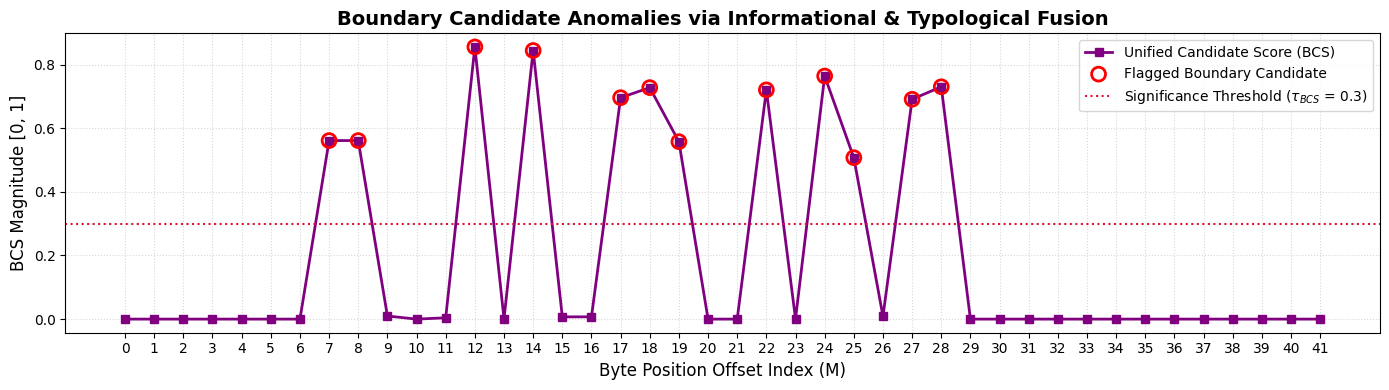

In [9]:
def plot_boundary_candidates(bcs_vector: np.ndarray, threshold: float = 0.3):
    """
    Plots the unified Boundary Candidate Scores across all byte positions,
    highlighting the locations where the threshold is breached.
    """
    plt.figure(figsize=(14, 4))
    x = np.arange(len(bcs_vector))
    
    # Plot the continuous fusion line
    plt.plot(x, bcs_vector, color='purple', linewidth=2, marker='s', label='Unified Candidate Score (BCS)')
    
    # Highlight points that cross our significance threshold
    candidates = np.where(bcs_vector >= threshold)[0]
    plt.scatter(candidates, bcs_vector[candidates], color='red', s=100, zorder=5, 
                facecolors='none', edgecolors='red', linewidths=2, label='Flagged Boundary Candidate')
    
    # Draw reference threshold line
    plt.axhline(y=threshold, color='crimson', linestyle=':', linewidth=1.5, label=f'Significance Threshold ($\\tau_{{BCS}}$ = {threshold})')
    
    plt.title("Boundary Candidate Anomalies via Informational & Typological Fusion", fontsize=14, fontweight='bold')
    plt.xlabel("Byte Position Offset Index (M)", fontsize=12)
    plt.ylabel("BCS Magnitude [0, 1]", fontsize=12)
    plt.xticks(x)
    plt.grid(axis='both', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Execute Visualization
plot_boundary_candidates(bcs_profile, threshold=TAU_BCS)

## Output Interpretation & Expected Observations

When analyzing the fused $BCS$ results, look for these specific validation indicators:
1. **Suppression of Subnet Noise:** In our raw entropy analysis, the transition at Offset 14 caused a large spike because the internal values changed. Now, because both Offset 13 and 14 share high-variance characteristics, the combined fusion score filters out that minor fluctuation, preventing an incorrect boundary flag.
2. **True Candidate Spikes:** Clear, unambiguous spikes crossing the $\tau_{BCS}$ threshold should appear at **Offset 7** (Invariants to Opcode transition), **Offset 12** (Opcode to Sender MAC transition), and **Offset 28** (Payload to Padding transition).

**Potential Failures to Note:** If two highly distinct protocol fields share identical FVI ranges and change classification categories at the same time, this stage might miss the boundary, resulting in under-segmentation. This is expected behavior at this stage, and it confirms why we need the sliding horizontal window check (KL Divergence) in the next phase to catch these subtle changes.

In [10]:
# --- Save artifacts for Notebook 06 ---
import os
import numpy as np

processed_dir = os.path.join("..", "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

# Save the unified BCS profile and identified candidates
np.save(os.path.join(processed_dir, "bcs_profile.npy"), bcs_profile)
np.save(os.path.join(processed_dir, "candidate_indices.npy"), candidate_indices)

print("Artifacts successfully serialized for KL Divergence refinement.")

Artifacts successfully serialized for KL Divergence refinement.
